In [99]:
import torch 
from matplotlib import pyplot as plt
import numpy as np

In [261]:

def init_(in_channels, out_channels, hidden_channels, layers): 
        
        theta_size = (in_channels*hidden_channels + hidden_channels) + \
                     (hidden_channels*hidden_channels + hidden_channels)*layers + \
                     (hidden_channels*out_channels + out_channels)
        
        W_indices = [torch.arange(in_channels*hidden_channels)]
        offset = in_channels*hidden_channels
        for l in range(layers): 
            W_indices.append( torch.arange(offset, offset + hidden_channels*hidden_channels) )
            offset += hidden_channels*hidden_channels
        W_indices.append(torch.arange(offset, offset + hidden_channels*out_channels))
        offset += hidden_channels*out_channels 
        bias_indices = [] 
        for i in range(layers + 1): 
            bias_indices.append( torch.arange(offset, offset + hidden_channels))
            offset += hidden_channels 
        bias_indices += torch.arange(offset, offset + out_channels)
        offset += out_channels

        assert theta_size == offset, f'expected theta_size ({theta_size}) to be the same as final offset ({offset})'

        return theta_size, W_indices, bias_indices

        
class GaNN(torch.nn.Module): 
    def __init__(self, in_channels, out_channels, hidden_channels, layers, gaussian_channels, width): 
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels 
        self.hidden_channels = hidden_channels
        self.layers = layers
        self.gaussian_channels =gaussian_channels
        self.width = width

        theta_size, W_indices, bias_indices = init_(in_channels, out_channels, hidden_channels, layers)

        self.W_sizes = [(in_channels, hidden_channels)] + [(hidden_channels, hidden_channels) for _ in range(layers)] + [(hidden_channels, out_channels)]
        for i,Widx in enumerate(W_indices): self.register_buffer(f'W{i}', Widx)
        for i,Bidx in enumerate(bias_indices): self.register_buffer(f'B{i}', Bidx)
        
        self.f_phi = torch.nn.Sequential(torch.nn.Linear(gaussian_channels, width, bias=False), 
                                         torch.nn.ReLU(), 
                                         torch.nn.Linear(width, theta_size, bias=False))

        self.gaussians = torch.distributions.Normal(torch.zeros((gaussian_channels), requires_grad=False), 
                                                    torch.ones((gaussian_channels), requires_grad=False))

    def forward(self, x, samples=3): 
        x = x.T.unsqueeze(0).expand(samples, -1, -1)
        # x size: (batch, in_channels)

        z = self.gaussians.sample((samples,))
        theta = self.f_phi(z)

        for i in range(self.layers + 1): 
            W = theta[:, getattr(self, f'W{i}')].view(-1, *self.W_sizes[i]) # size (samples, channels_in, channels_out)
            B = theta[:, getattr(self, f'B{i}')].unsqueeze(2)               # size (samples, 1, channels_out)
            x = torch.matmul(W.permute(0,2,1), x) + B                                    # size (samples, )
            x = x.relu() 
        
        W = theta[:, getattr(self, f'W{self.layers+1}')].view(-1, *self.W_sizes[self.layers+1])
        B = theta[:, getattr(self, f'B{self.layers+1}')].view(-1,self.out_channels,1)
        x = torch.matmul(W.permute(0,2,1), x) + B
        return x.permute(0,2,1)


In [262]:
model = GaNN(in_channels=1, 
             out_channels=1, 
             hidden_channels=100, 
             layers=1, 
             gaussian_channels=10, 
             width=10)
x = torch.randn((10,1))
model(x)

tensor([[[ 0.1433],
         [-0.0364],
         [ 0.1041],
         [ 0.4501],
         [-0.0367],
         [ 0.4697],
         [ 0.4689],
         [-0.0653],
         [ 0.7024],
         [ 0.1560]],

        [[ 2.2819],
         [ 1.4330],
         [ 2.1336],
         [-0.2520],
         [ 1.4313],
         [-0.2445],
         [-0.0961],
         [ 1.0697],
         [ 0.8308],
         [ 2.4426]],

        [[ 0.0253],
         [ 0.0414],
         [ 0.0644],
         [ 0.2518],
         [ 0.0414],
         [ 0.2578],
         [ 0.2765],
         [ 0.0269],
         [ 0.2986],
         [-0.1982]]], grad_fn=<PermuteBackward0>)

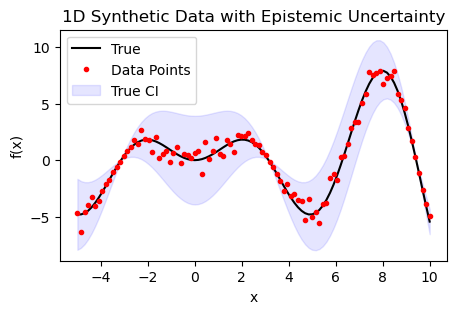

In [265]:

def f(x, noise=False):
    if noise: 
        return x*torch.sin(x) + torch.randn_like(x)*torch.cos(x/2), x*torch.sin(x) - 3.92*torch.cos(x/2), x*torch.sin(x) + 3.92*torch.cos(x/2)
    else: 
        return x*torch.sin(x)

x = torch.linspace(-5,10,100)
y_true = f(x)
y, true_lcb, true_ucb = f(x, noise=True)


plt.figure(figsize=(5, 3))
plt.plot(x.numpy(), y_true.numpy(), 'k-', label='True')
plt.plot(x.numpy(), y.numpy(), 'r.', label='Data Points')
plt.fill_between(x,
                 true_lcb,
                 true_ucb,
                 color='blue', alpha=0.1, label='True CI')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('1D Synthetic Data with Epistemic Uncertainty')
plt.legend()
plt.show()

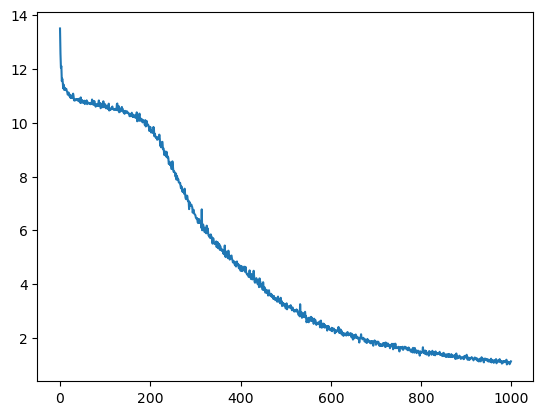

In [306]:
x = x.view(-1,1)
y = y.view(-1,1)

model = GaNN(in_channels=1, 
             out_channels=1, 
             hidden_channels=25, 
             layers=2, 
             gaussian_channels=5, 
             width=200)

optim = torch.optim.Adam(model.parameters(), lr=1e-4)
crit = torch.nn.MSELoss()

num_epochs = 1000
samples = 1000 

losses = []
for i in range(num_epochs): 
    optim.zero_grad()

    yhat = model(x, samples=samples)
    loss = crit(y.unsqueeze(0).expand(samples,-1,-1), yhat)
    loss.backward()
    optim.step()
    losses.append(loss.item())
    print(f'progress: {i}/{num_epochs} --> loss: {losses[-1]:.3f}', end='\r')

plt.figure()
plt.plot(losses)
plt.show()

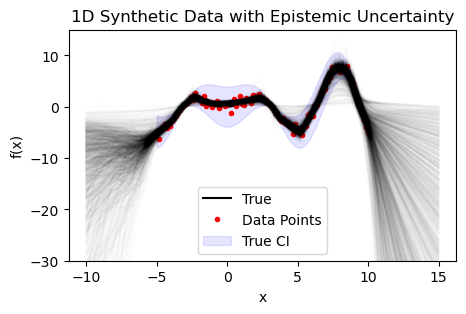

In [307]:
plt.figure(figsize=(5, 3))
plt.plot(x.squeeze().numpy(), y_true.numpy(), 'k-', label='True')
plt.plot(x.squeeze().numpy(), y.squeeze().numpy(), 'r.', label='Data Points')
plt.fill_between(x.squeeze(),
                 true_lcb,
                 true_ucb,
                 color='blue', alpha=0.1, label='True CI')

x2 = torch.linspace(-10,15,100)

yhat = model(x2.unsqueeze(1), 1000)
for yyhat in yhat: 
    plt.plot(x2, yyhat.detach().numpy(), 'k-', alpha=0.01)
    
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('1D Synthetic Data with Epistemic Uncertainty')
plt.legend()
plt.ylim(-30,15)
plt.show()